# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python13 - Logistic Regression</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **🔹 What is Logistic Regression?**
Logistic Regression is a **supervised learning algorithm** used for **binary classification** problems. Unlike linear regression, which predicts continuous values, **logistic regression predicts the probability** of a given class.

### **Key Characteristics:**
✅ Used for **binary classification** (Yes/No, Spam/Not Spam, Churn/No Churn).  
✅ Outputs a probability score between **0 and 1**.  
✅ Uses the **sigmoid function** to map any real-valued number into the range **(0,1)**.  
✅ The decision boundary is defined by a threshold (e.g., **0.5**).  

---

## **🔹 The Logistic (Sigmoid) Function**
The logistic function is given by:


$\sigma(z) = \frac{1}{1 + e^{-z}}
$

where:


$z = w_1 X_1 + w_2 X_2 + ... + w_n X_n + b = \mathbf{w}^T \mathbf{x} + b$

- $ X $ = feature vector  
- $ w $ = weight coefficients  
- $ b $ = bias term  
- $ e $ = Euler’s number (**≈ 2.718**)  

The output of the function is a probability value between **0 and 1**.

**Decision Rule:**  
$
\hat{y} =
\begin{cases} 
1, & \text{if } \sigma(z) \geq 0.5 \\ 
0, & \text{otherwise}
\end{cases}
$

🚀 **Interpretation:**  
- If **\( P(y=1 | X) \) ≥ 0.5**, classify the input as **Class 1**.  
- If **\( P(y=1 | X) \) < 0.5**, classify the input as **Class 0**.

---

## **🔹 Cost Function for Logistic Regression**
Logistic Regression **does not** use Mean Squared Error (MSE) as its cost function because it leads to a **non-convex** function, making optimization difficult.

Instead, if we maximizes the likelihood
$$ L(w) :=P(Y_1=y_1,\ldots,Y_m=y_m|w,x_1,\dots,x_m) =\Pi_{i=1}^nP(Y_i=y_i|w,x_1,\dots,x_m). $$
Assuming independence:
$$ L(w) := \prod_{i|y_i=1} p(x_i) * \prod_{i|y_i=0}(1- p(x_i)) $$
$$ L(w) := \prod_{i=1}^n p(x_i)^{y_i}(1- p(x_i))^{1-y_i} $$

is equivalent to maximize the log likelihood

$$l(w)=\sum_{i=1}^n (y_i log(p(x_i)) + (1-y_i) log(1- p(x_i)) )$$
$$ = \sum_{i=1}^n (y_i log(\frac{p(x_i}{1-p(x_i)}) + log(1-p(x_i))) $$


Therefore we aim to resolve the following optimization problem
$$\min_{w} \frac{1}{2}||w||^2 + C \sum_{i=1}^n (y_i w^T x_i) - log(1-e^{w^T x_i})) $$


## **🔹 Logistic Regression vs Linear Regression**
| Feature | Linear Regression | Logistic Regression |
|---------|------------------|----------------------|
| **Output Type** | Continuous | Probability (0-1) |
| **Function Used** | Linear Equation | Sigmoid Function |
| **Use Case** | Regression | Classification |
| **Loss Function** | Mean Squared Error (MSE) | Log Loss (Binary Cross Entropy) |
| **Decision Boundary** | Any real number | Threshold (0.5) |

---

## **🔹 Visual Representation of Logistic Regression**


![Logistic Regression Visualization](https://www.saedsayad.com/images/LogReg_1.png)



---

## **🎯 Summary**
✅ Logistic Regression is used for **classification** tasks, not regression.  
✅ Uses the **sigmoid function** to map real values to probabilities.  
✅ The **cost function is Log Loss**, optimized using **Gradient Descent**.  
✅ The **decision threshold (0.5)** determines classification.  

🚀 **Next Steps:** Implement Logistic Regression in Python using `scikit-learn`! 🏆
---

# Data Loading

In [1]:
import pandas as pd
data = pd.read_csv('diabetes.csv')

In [2]:
X = data.iloc[:,0:-1]
column_names = list(X) 
y = data.iloc[:,-1] 

from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import MinMaxScaler
'''
USING STANDARDSCALER:

Standardize features by removing the mean and scaling to unit variance

Centering and scaling happen independently on each feature by computing the relevant statistics on the samples in the training set. Mean and standard deviation are then stored to be used on later data using the transform method.

Standardization of a dataset is a common requirement for many machine learning estimators: they might behave badly if the individual features do not more or less look like standard normally distributed data (e.g. Gaussian with 0 mean and unit variance).
'''

scaler = StandardScaler().fit(X) 

X_scaled = scaler.transform(X)

X_scaled = pd.DataFrame(X_scaled)
X_scaled.columns = column_names

from sklearn.model_selection import train_test_split #like usual

#SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y,  #X_scaled
                                                    test_size =0.30, #by default is 75%-25%
                                                    #shuffle is set True by default,
                                                    stratify=y,
                                                    random_state= 123) #fix random seed for replicability

print(X_train.shape)

(537, 8)


# Logistic Regression Model

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">
 
## **Exercise: Logistic Regression Model Selection and Coefficients Analysis**

#### **Objective**
In this exercise, you will:
- Tune hyperparameters of **Logistic Regression** using **GridSearchCV**.
- Evaluate model performance using **recall** as the primary metric.
- Analyze **feature coefficients** to interpret the importance of each feature.

---

#### **Steps to Complete**

### **1️⃣ Train and Optimize a Logistic Regression Model**
1. Define a **Logistic Regression classifier**.
2. Set up a **GridSearchCV** to tune hyperparameters:
   - Regularization strength (**C**): `[0.01, 0.1, 1]`
   - Penalty: `'l2'`
   - Maximum iterations: `[50000, 10000]`
3. Use **3-fold cross-validation** (`cv=3`) and optimize based on **recall**.


---

### **2️⃣ Evaluate Performance on the Test Set**
- Retrieve the best model from GridSearch.
- Predict on **both training and test sets**.
- Calculate **F1-score** to evaluate performance.


---

### **3️⃣ Feature Importance: Analyzing Coefficients**
- Retrieve model coefficients.
- Zip feature names with their respective coefficients.
- **Plot feature importance** using a bar plot.


---

### **4️⃣ Evaluate Model Performance with ROC Curve**
- Compute **ROC Curve** and **AUC score**.
- Plot **ROC Curve** to visualize model discrimination power.

---

### **Discussion Questions**
1. **Why do we optimize recall instead of accuracy in this case?**
2. **What does the sign of the coefficients tell us about the relationship between each feature and the target?**
3. **How does regularization (`C` parameter) affect feature importance?**
4. **What do you observe in the ROC Curve? Does the model have good discrimination power?** 

---

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

classifier = LogisticRegression()
parameters = {"C": [1e-2, 1e-1, 1], "penalty": ['l2'], "max_iter": [50000, 10000]}

gs = GridSearchCV(classifier, parameters, cv=3, scoring='recall', verbose=50, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best score: 0.571685 using {'C': 0.1, 'max_iter': 50000, 'penalty': 'l2'}


c:\Users\kso\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [4]:
from sklearn import metrics

best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print('***RESULTS ON TRAIN SET***')
print("F1 Score: ", metrics.f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("F1 Score: ", metrics.f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
F1 Score:  0.6567164179104478
--
***RESULTS ON TEST SET***
F1 Score:  0.6056338028169014


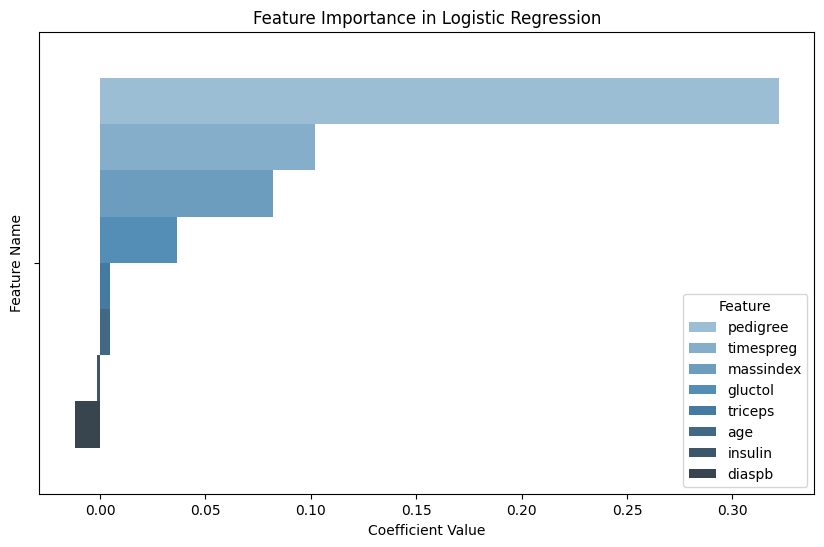

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Retrieve coefficients
feature_importance = list(zip(X_train.columns, best_model.coef_[0,:]))

# Convert to DataFrame
import pandas as pd
importance_df = pd.DataFrame(feature_importance, columns=['Feature', 'Coefficient'])
importance_df = importance_df.sort_values(by="Coefficient", ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", hue="Feature", data=importance_df, palette="Blues_d")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Logistic Regression")
plt.savefig("figures/features_importances_lr.png")
plt.show()

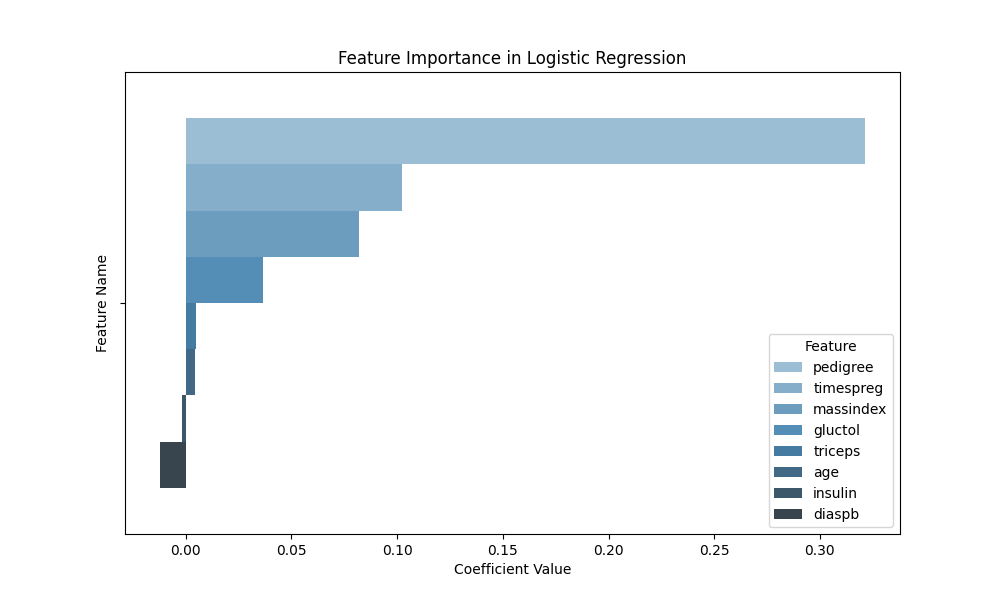

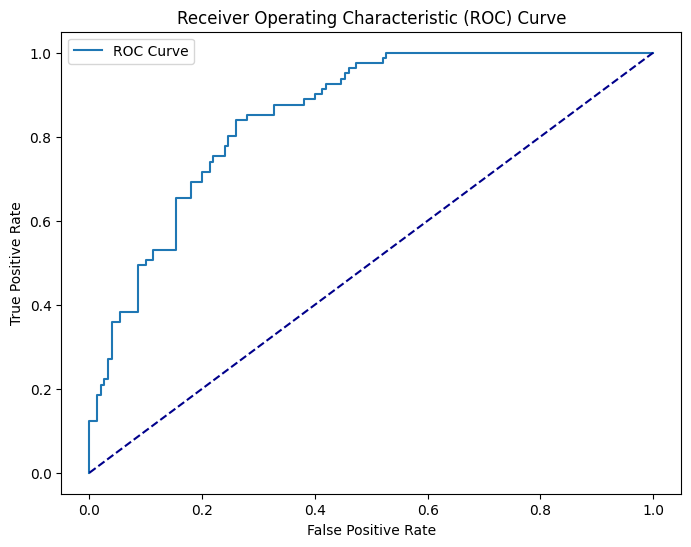

AUC Score: 0.85


In [6]:
from sklearn import metrics

# Predict Probabilities
y_probs = best_model.predict_proba(X_test)[:,1]  # Probabilities for class 1

# Compute ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Compute AUC Score
auc_score = metrics.roc_auc_score(y_test, y_probs)
print(f'AUC Score: {auc_score:.2f}')